In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random

In [2]:
data_path = 'data'

In [3]:
def get_random_symbol_image(char):
        folder_name = char
        if (char == 'x'):
            folder_name = 'X'
        if (char == '*'):
            folder_name = 'times'
        symbol_dir = os.path.join(data_path, folder_name)
        
        images = [f for f in os.listdir(symbol_dir)]
        images.sort() 
        start_index = int(len(images) * 0.8)
        last_30_percent = images[start_index:]

        random_image = random.choice(last_30_percent)
        img_path = os.path.join(symbol_dir, random_image)
        
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)    
        return img

In [4]:
get_random_symbol_image('+')

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)

In [5]:
available_symbols = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', 'X', '*', 'h', 'y', 'w', 't', '-', '(', ')', ',']

In [6]:
def generate_sequence(length=4):
    sequence = ''.join(random.choices(available_symbols, k=length))
    images = []
    
    for char in sequence:
        img = get_random_symbol_image(char)
        if img is not None:
            images.append(img)
    
    return sequence, images

In [7]:
generate_sequence(4)

('1(15',
 [array([[255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         ...,
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255]], dtype=uint8),
  array([[255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         ...,
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255]], dtype=uint8),
  array([[255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         ...,
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255]], dtype=uint8),
  array([[255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 

In [8]:
def create_sequence_image(images, spacing=10):
    total_width = sum(img.shape[1] for img in images) + spacing * (len(images) - 1)
    max_height = max(img.shape[0] for img in images)
    
    sequence_img = np.ones((max_height, total_width), dtype=np.uint8) * 255
    
    x_offset = 0
    for img in images:
        h, w = img.shape
        y_offset = (max_height - h)
        sequence_img[y_offset:y_offset+h, x_offset:x_offset+w] = img
        x_offset += w + spacing
    
    return sequence_img

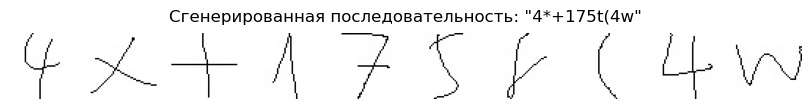

In [9]:
sequence, images = generate_sequence(length=10)
sequence_image = create_sequence_image(images)

fig, ax = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)
ax.imshow(sequence_image, cmap='gray')
ax.set_title(f'Сгенерированная последовательность: "{sequence}"', fontsize=12, pad=8)
ax.axis('off')
plt.show()


In [10]:
img_gray = sequence_image.copy()
kernel = np.ones((3,3),np.uint8)
img_gray = cv2.erode(img_gray,kernel, iterations = 1)
img_gray = cv2.bitwise_not(img_gray)

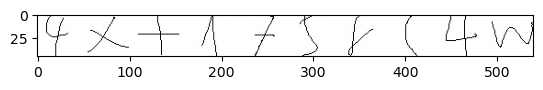

In [11]:
plt.subplot(1, 1, 1)
plt.imshow(sequence_image, cmap='gray')
plt.show()

In [12]:
base_size=img_gray.shape[0]+6,img_gray.shape[1]+6
base=np.zeros(base_size,dtype=np.uint8)
base[3:img_gray.shape[0]+3,3:img_gray.shape[1]+3]=img_gray
base = cv2.cvtColor(base, cv2.COLOR_GRAY2RGB)
img_rgb = base.copy()

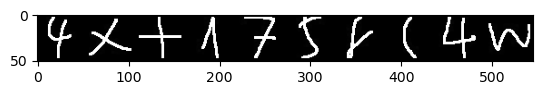

In [13]:
plt.subplot(1, 1, 1)
plt.imshow(img_rgb)
plt.show()

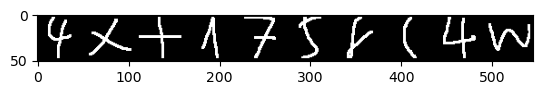

In [14]:
ret,thresh = cv2.threshold(img_rgb,127,255,0)
thresh = np.uint8(thresh)

plt.subplot(1, 1, 1)
plt.imshow(thresh)
plt.show()

contours,h = cv2.findContours(thresh[:,:,0], cv2.RETR_EXTERNAL, 2)

In [15]:
crops = []
for i in range(len(contours)):
    cnt = contours[i]
    area = cv2.contourArea(cnt)
    x,y,w,h = cv2.boundingRect(cnt)
    if w*h > 50:
        cv2.rectangle(img_rgb,(x,y),(x+w,y+h),(0,0,255),2)
        ret,thresh = cv2.threshold(img_gray[y:y+h, x:x+w],127,255,0)
        crops.append([x,y,w,h]) 

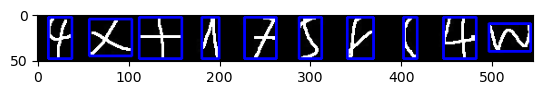

In [16]:
plt.subplot(1, 1, 1)
plt.imshow(img_rgb)
plt.show()

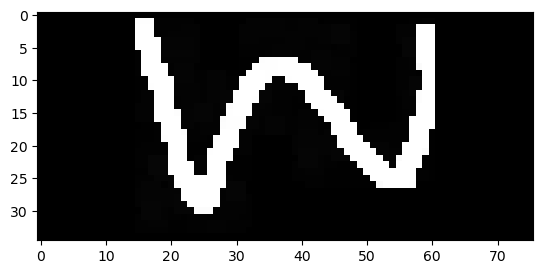

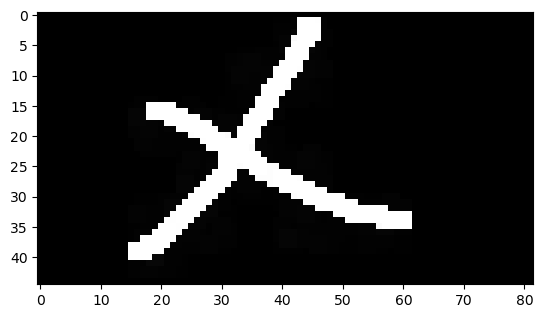

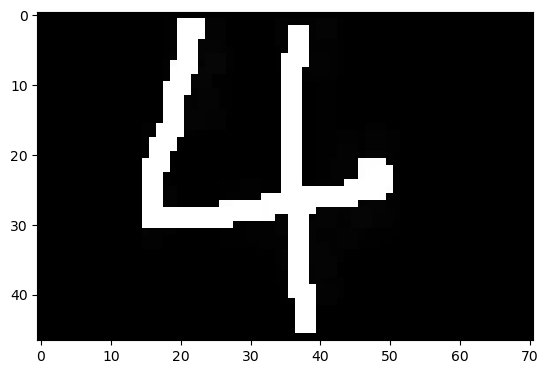

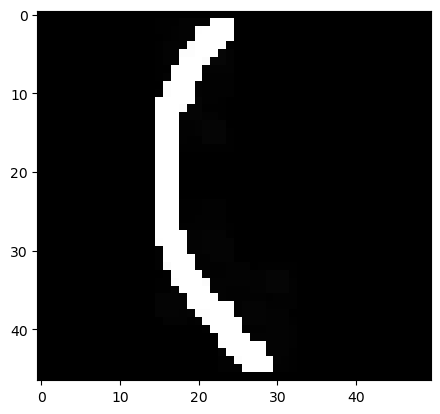

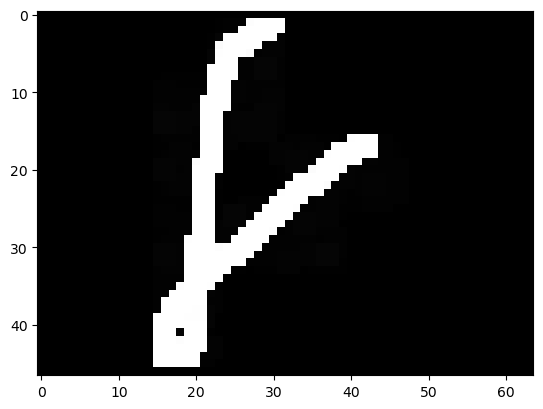

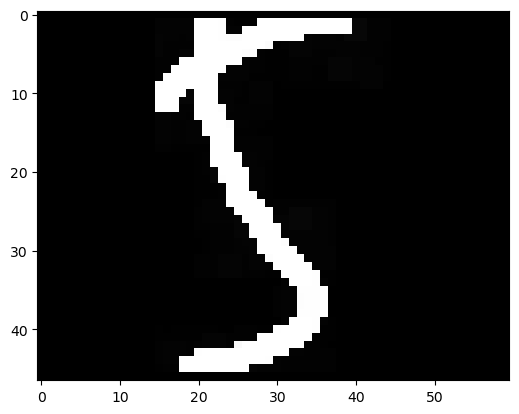

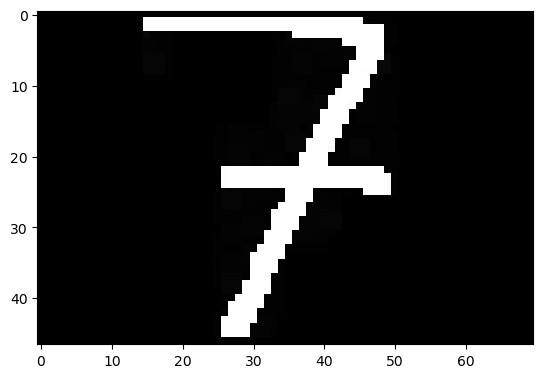

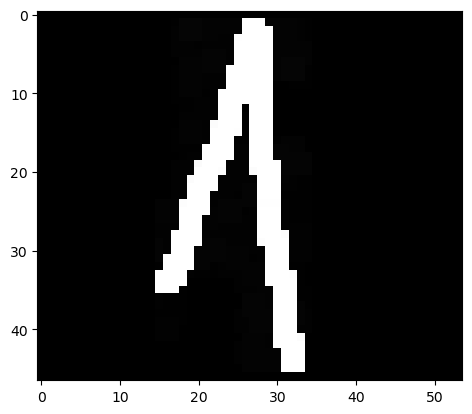

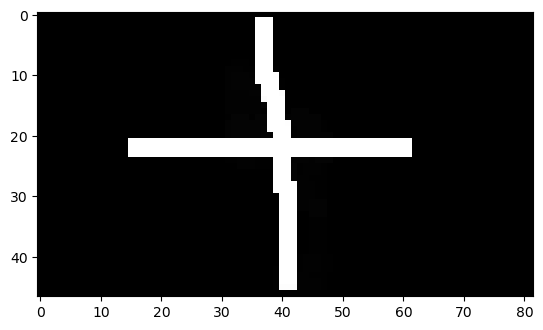

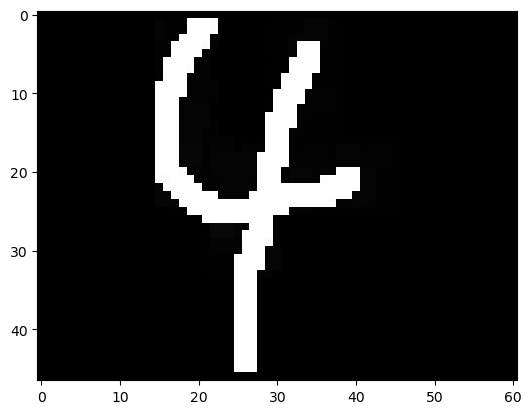

In [17]:
data_img= []
for i in range(len(crops)):
    x,y,w,h = crops[i]
    x-=3
    y-=3
    w+=5
    h+=3
    img = img_gray[y:y+h, x:x+w]
    base_size=img.shape[0]+2,img.shape[1]+30
    base=np.zeros(base_size,dtype=np.uint8)
    base[1:img.shape[0]+1,15:img.shape[1]+15]=img
    plt.imshow(base, cmap="gray")
    data_img.append((x,base))
    plt.show()

In [18]:
def center_to_square(image, target_size=49):

    h, w = image.shape
    if h > target_size or w > target_size:
        scale = min(target_size / h, target_size / w)
        new_h = max(1, int(h * scale))
        new_w = max(1, int(w * scale))
        image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)
        h, w = image.shape

    squared = np.zeros((target_size, target_size), dtype=image.dtype)

    y_offset = (target_size - h) // 2
    x_offset = (target_size - w) // 2


    squared[y_offset:y_offset + h, x_offset:x_offset + w] = image
    return squared


In [19]:
resized_symbols = []
for x, symbol_img in data_img:
    centered_img = center_to_square(symbol_img)
    resized_symbols.append((x, centered_img))
    


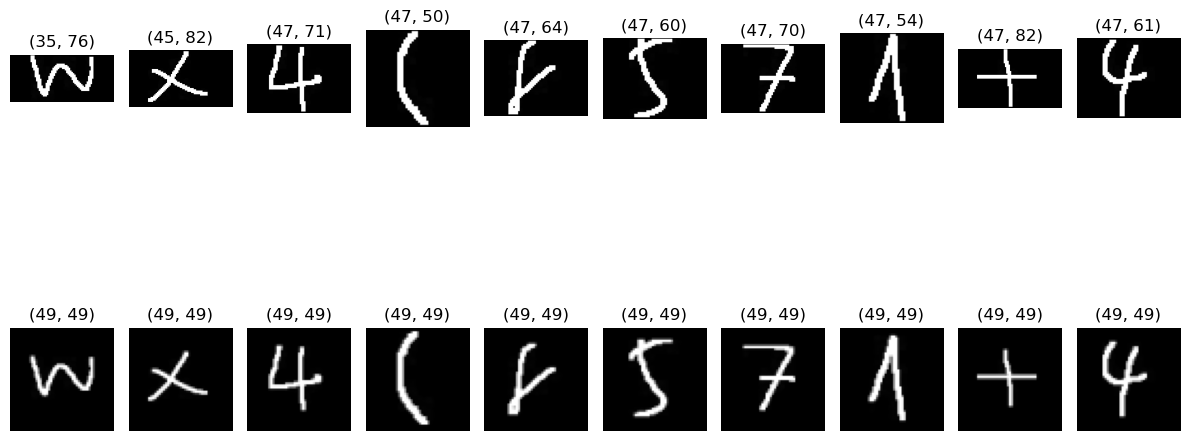

In [20]:
fig, axes = plt.subplots(2, 10, figsize=(12, 8))

for i in range(10):
    x1, orig_img = data_img[i]          
    x2, resized_img = resized_symbols[i]  

    axes[0, i].imshow(orig_img, cmap='gray')
    axes[0, i].set_title(orig_img.shape)
    axes[0, i].axis('off')
    
    axes[1, i].imshow(resized_img, cmap='gray')
    axes[1, i].set_title(resized_img.shape)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


In [21]:
def load_training_data(data_path, symbols, train_size=0.7, target_size=45, max_images_per_symbol=3000):
    X_train, y_train = [], []

    label_map = {
        'X': 'x',
        'times': '*',
    }

    for symbol in symbols:
        symbol_path = os.path.join(data_path, symbol)
        
        images = sorted(
            f for f in os.listdir(symbol_path)
            if os.path.isfile(os.path.join(symbol_path, f))
        )
        
        random.shuffle(images)
        images = images[:max_images_per_symbol]

        split_idx = int(len(images) * train_size)
        train_images = images[:split_idx]

        label = label_map.get(symbol, symbol)

        for img_name in train_images:
            img_path = os.path.join(symbol_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            img_norm = img

            img_centered = center_to_square(img_norm, target_size=target_size)

            X_train.append(img_centered.flatten())
            y_train.append(label)

    X_train = np.array(X_train, dtype=np.float32)
    y_train = np.array(y_train)

    return X_train, y_train

In [22]:
symbols = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '+', 'X', 'times', 'h', 'y', 'w', 't', '-', '(', ')', ',']
data_path = "./data" 

X_train, y_train = load_training_data(data_path, symbols, train_size=0.7, target_size=49, max_images_per_symbol=6000)


In [23]:
X_train[0]

array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from tqdm import tqdm

def evaluate_knn_models(X_train, y_train, X_test, y_test, k_values):
    results = {}

    for k in tqdm(k_values):
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        results[k] = acc
        print(f"k = {k} → accuracy = {acc:.4f}")

    return results


In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42, stratify=y_train
)

In [26]:
k_list = [1, 3, 5, 7, 9, 11]

results = evaluate_knn_models(
    X_train, y_train,
    X_test,  y_test,
    k_list
)


 17%|█▋        | 1/6 [03:27<17:16, 207.20s/it]

k = 1 → accuracy = 0.8075


 33%|███▎      | 2/6 [07:43<15:44, 236.24s/it]

k = 3 → accuracy = 0.6200


 50%|█████     | 3/6 [11:57<12:12, 244.29s/it]

k = 5 → accuracy = 0.5247


 67%|██████▋   | 4/6 [15:48<07:57, 238.82s/it]

k = 7 → accuracy = 0.4815


 83%|████████▎ | 5/6 [18:50<03:38, 218.60s/it]

k = 9 → accuracy = 0.4455


100%|██████████| 6/6 [21:28<00:00, 214.83s/it]

k = 11 → accuracy = 0.4210


In [27]:
best_k = max(results, key=results.get)
best_acc = results[best_k]
print(f"\nЛучший k = {best_k}, accuracy = {best_acc:.4f}")


,Лучший k = 1, accuracy = 0.8075


In [30]:
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Распознанная строка: 983h230t-7


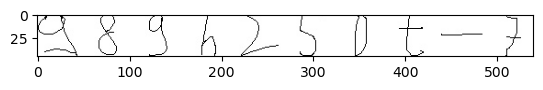

In [31]:
sequence, images = generate_sequence(length=10)
sequence_image = create_sequence_image(images)

recognized_chars = []

for img in images:
    img = center_to_square(img, target_size=49)
    vec = img.flatten().reshape(1, -1)   
    pred = best_knn.predict(vec)[0]
    recognized_chars.append(pred)

recognized_text = "".join(recognized_chars)
print("Распознанная строка:", recognized_text)
plt.imshow(sequence_image, cmap='gray')


# Проверка на 100 последовательностях

In [33]:
total_accuracy = 0
num_tests = 100
length_seq = 10

for _ in range(num_tests):
    sequence, images = generate_sequence(length_seq)
    sequence_image = create_sequence_image(images)

    recognized_chars = []

    for img in images:
        img = center_to_square(img, target_size=49)
        vec = img.flatten().reshape(1, -1)   
        pred = best_knn.predict(vec)[0]
        recognized_chars.append(pred)

    recognized_text = "".join(recognized_chars)
    
    correct = sum(1 for a, b in zip(sequence, recognized_text) if a == b)
    accuracy = correct / len(sequence)
    total_accuracy += accuracy

    if _ % 20 == 0:
        print(f"Исходная: {sequence} | Распознанная: {recognized_text} | Точность: {accuracy:.2f}")

average_accuracy = total_accuracy / num_tests
print(f"\nСредняя точность распознавания за {num_tests} тестов: {average_accuracy:.4f}")


Исходная: (7)3187h8t | Распознанная: (7)2187h8t | Точность: 0.90
,Исходная: (791*t,,7w | Распознанная: (7)1*t,,1w | Точность: 0.80
,Исходная: 9,+76ty+w* | Распознанная: 9117(ty1w* | Точность: 0.60
,Исходная: (2+5h77+(0 | Распознанная: (1+5h7t-(0 | Точность: 0.70
,Исходная: 47-)h*-ty2 | Распознанная: 47-)h*-ty2 | Точность: 1.00
,
,Средняя точность распознавания за 100 тестов: 0.8190
